# Skip-gram Word2Vec
This notebook implements the Skip-gram version of Word2Vec on the Rotten Tomatoes movie review dataset.

## 1. Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import re
from datasets import load_dataset
from tqdm import tqdm
import random

## 2. Loading a dataset

In [9]:
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'\W', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\d', ' ', text)
    return text.strip()

ds = load_dataset("cornell-movie-review-data/rotten_tomatoes")
train_texts = [preprocess_text(t) for t in ds['train']['text']]
train_labels = ds['train']['label']

## 3. Prepare training pairs

In [10]:
corpus = " ".join(train_texts)
words = corpus.split()
vocab = list(set(words))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in word2idx.items()}
V = len(vocab)

window_size = 2
data = []
for i in range(window_size, len(words) - window_size):
    target = words[i]
    context = words[i-window_size:i] + words[i+1:i+window_size+1]
    for ctx_word in context:
        data.append((target, ctx_word))

## 4. Model setup and training loop

In [ ]:
embedding_dim = 10
W1 = np.random.randn(V, embedding_dim)
W2 = np.random.randn(embedding_dim, V)

selected_words = ['movie', 'film', 'actor', 'director', 'comedy', 'drama', 'good', 'bad', 'love', 'hate']
selected_idxs = [word2idx[w] for w in selected_words if w in word2idx]
embeddings_before = W1[selected_idxs]
cos_sim_before = np.dot(embeddings_before, embeddings_before.T) / (
    np.linalg.norm(embeddings_before, axis=1)[:, None] * np.linalg.norm(embeddings_before, axis=1)[None, :]
)

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def forward(target_idx):
    h = W1[target_idx]
    u = np.dot(h, W2)
    y_pred = softmax(u)
    return y_pred, h

def backward(target_idx, context_idx, y_pred, h, lr=0.05):
    global W1, W2
    e = y_pred.copy()
    e[context_idx] -= 1
    dW2 = np.outer(h, e)
    dW1 = np.dot(W2, e)
    W1[target_idx] -= lr * dW1
    W2 -= lr * dW2

epochs = 10
for epoch in tqdm(range(epochs)):
       random.shuffle(data) 
    for target, context in data[:50000]:
    # for target, context in data:
        target_idx = word2idx[target]
        context_idx = word2idx[context]
        y_pred, h = forward(target_idx)
        backward(target_idx, context_idx, y_pred, h)
    print(f"Epoch {epoch+1} finished")

 10%|█         | 1/10 [04:40<42:07, 280.89s/it]

Epoch 1 finished


 20%|██        | 2/10 [09:28<37:57, 284.66s/it]

Epoch 2 finished


 30%|███       | 3/10 [14:34<34:20, 294.33s/it]

...

Epoch 8 finished


 90%|█████████ | 9/10 [42:56<04:37, 277.47s/it]

Epoch 9 finished


100%|██████████| 10/10 [47:11<00:00, 283.15s/it]

Epoch 10 finished


## 5. Visualization and analysis

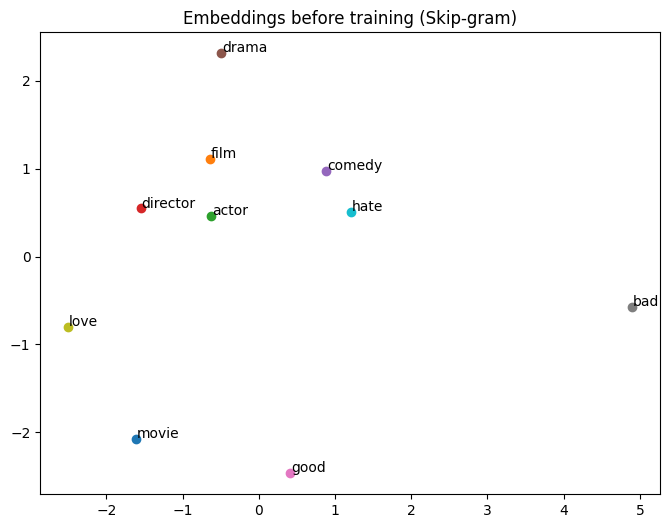

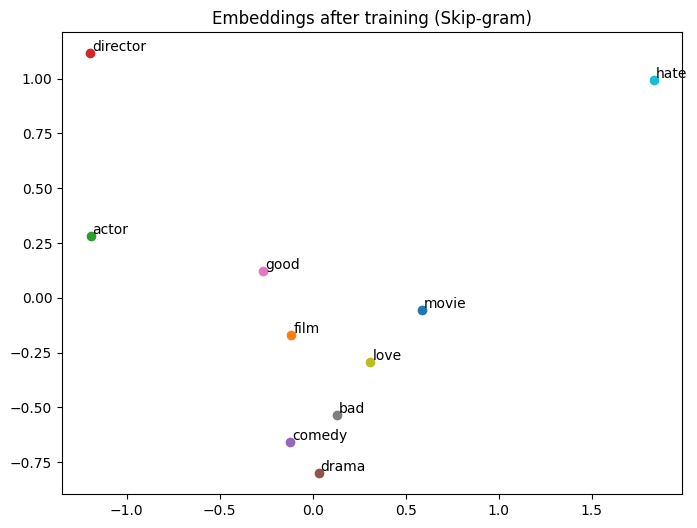

Cosine similarity before training:
 [[ 1.   -0.13  0.25  0.27 -0.05 -0.35  0.35 -0.52  0.48 -0.4 ]
 [-0.13  1.    0.06  0.41 -0.12  0.21 -0.09 -0.29  0.22 -0.07]
 [ 0.25  0.06  1.    0.3   0.33  0.25 -0.09 -0.29  0.55  0.34]
 [ 0.27  0.41  0.3   1.   -0.26  0.28 -0.12 -0.68  0.46 -0.03]
 [-0.05 -0.12  0.33 -0.26  1.    0.3   0.11 -0.1  -0.29  0.53]
 [-0.35  0.21  0.25  0.28  0.3   1.   -0.49 -0.48  0.07  0.14]
 [ 0.35 -0.09 -0.09 -0.12  0.11 -0.49  1.   -0.05  0.13  0.33]
 [-0.52 -0.29 -0.29 -0.68 -0.1  -0.48 -0.05  1.   -0.58  0.17]
 [ 0.48  0.22  0.55  0.46 -0.29  0.07  0.13 -0.58  1.   -0.11]
 [-0.4  -0.07  0.34 -0.03  0.53  0.14  0.33  0.17 -0.11  1.  ]]
Cosine similarity after training:
 [[1.   0.9  0.59 0.49 0.88 0.88 0.87 0.84 0.85 0.82]
 [0.9  1.   0.67 0.62 0.92 0.87 0.94 0.81 0.78 0.62]
 [0.59 0.67 1.   0.78 0.65 0.57 0.8  0.44 0.48 0.24]
 [0.49 0.62 0.78 1.   0.45 0.39 0.72 0.35 0.37 0.32]
 [0.88 0.92 0.65 0.45 1.   0.94 0.83 0.84 0.71 0.51]
 [0.88 0.87 0.57 0.39 0.94 1.   0

In [ ]:
embeddings_after = W1[selected_idxs]
cos_sim_after = np.dot(embeddings_after, embeddings_after.T) / (
    np.linalg.norm(embeddings_after, axis=1)[:, None] * np.linalg.norm(embeddings_after, axis=1)[None, :]
)

def plot_embeddings(embeddings, words, title):
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(embeddings)
    plt.figure(figsize=(8,6))
    for i, word in enumerate(words):
        plt.scatter(emb_2d[i,0], emb_2d[i,1])
        plt.text(emb_2d[i,0]+0.01, emb_2d[i,1]+0.01, word)
    plt.title(title)
    plt.show()

plot_embeddings(embeddings_before, selected_words, "Embeddings before training (Skip-gram)")
plot_embeddings(embeddings_after, selected_words, "Embeddings after training (Skip-gram)")

print("Cosine similarity before training:\n", np.round(cos_sim_before, 2))
print("Cosine similarity after training:\n", np.round(cos_sim_after, 2))

The model was trained with a context window of 2 for 10 epochs. The matrices above show cosine similarity for selected words before and after training. You can see that similarity values increased substantially for many pairs — this indicates that the embeddings of words that appeared in similar contexts moved closer to each other.